In [1]:
import os
import pandas as pd
import kagglehub
import os

print(os.listdir("/kaggle/input"))

path = '/kaggle/input/datasets/adityajanjiree/bone-cancer'
dataset_path = os.path.join(path, "BTXRD")

# path
images_path = os.path.join(dataset_path, "images")
excel_path = os.path.join(dataset_path, "dataset.xlsx")

# load data
df = pd.read_excel(excel_path)

print("Total data awal:", len(df))

# filter lower limb
df = df[df["lower limb"] == 1].copy()

print("Total data lower limb:", len(df))
print(df.head())

['datasets']
Total data awal: 3746
Total data lower limb: 2406
         image_id  center  age gender  hand  ulna  radius  humerus  foot  \
1  IMG000002.jpeg       1   12      M     0     0       0        0     0   
2  IMG000003.jpeg       1   12      M     0     0       0        0     0   
3  IMG000004.jpeg       1   52      M     0     0       0        0     1   
4  IMG000005.jpeg       1   52      M     0     0       0        0     1   
5  IMG000006.jpeg       1   62      M     0     0       0        0     0   

   tibia  ...  synovial osteochondroma  other bt  osteosarcoma  other mt  \
1      1  ...                        0         0             1         0   
2      1  ...                        0         0             1         0   
3      0  ...                        0         0             1         0   
4      0  ...                        0         0             1         0   
5      0  ...                        0         0             1         0   

   upper limb  lower li

In [2]:
# buat label baru
def map_label(row):
    if row["malignant"] == 1:
        return "malignant"
    elif row["benign"] == 1:
        return "benign"
    else:
        return "normal"

df["label"] = df.apply(map_label, axis=1)

# cek distribusi
print("\nDistribusi kelas:")
print(df["label"].value_counts())


Distribusi kelas:
label
normal       1095
benign       1081
malignant     230
Name: count, dtype: int64


In [3]:
# buat path gambar
df["image_path"] = df["image_id"].apply(
    lambda x: os.path.join(images_path, x)
)

# dataframe final
df_model = df[["image_path", "label"]].copy()

print("\nContoh data:")
print(df_model.head())


Contoh data:
                                          image_path      label
1  /kaggle/input/datasets/adityajanjiree/bone-can...  malignant
2  /kaggle/input/datasets/adityajanjiree/bone-can...  malignant
3  /kaggle/input/datasets/adityajanjiree/bone-can...  malignant
4  /kaggle/input/datasets/adityajanjiree/bone-can...  malignant
5  /kaggle/input/datasets/adityajanjiree/bone-can...  malignant


In [4]:
# SPLIT DATA ======================================================
from sklearn.model_selection import train_test_split

train_df, temp_df = train_test_split(
    df_model,
    test_size=0.2,
    stratify=df_model["label"],
    random_state=42
)

val_df, test_df = train_test_split(
    temp_df,
    test_size=0.5,
    stratify=temp_df["label"],
    random_state=42
)

print("Train:", len(train_df))
print("Validation:", len(val_df))
print("Test:", len(test_df))

print("\nDistribusi train:")
print(train_df["label"].value_counts())

Train: 1924
Validation: 241
Test: 241

Distribusi train:
label
normal       876
benign       864
malignant    184
Name: count, dtype: int64


In [5]:
# # UNDERSAMPLING + AUGMENTASI =====================================
# import numpy as np

# TARGET = 200  # fleksibel

# balanced_list = []

# for label in train_df["label"].unique():
#     df_class = train_df[train_df["label"] == label]

#     if len(df_class) > TARGET:
#         df_class = df_class.sample(TARGET, random_state=42)

#     balanced_list.append(df_class)

# train_df = pd.concat(balanced_list)

# print("Distribusi setelah undersampling:")
# print(train_df["label"].value_counts())

2026-06-13 01:15:24.692284: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1781313324.936116      22 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1781313325.001183      22 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1781313325.547484      22 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1781313325.547523      22 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1781313325.547526      22 computation_placer.cc:177] computation placer alr

Mulai pipeline FINAL...
Class weight: {0: np.float64(0.7422839506172839), 1: np.float64(3.4855072463768115), 2: np.float64(0.7321156773211568)}

Menampilkan semua tahap preprocessing...


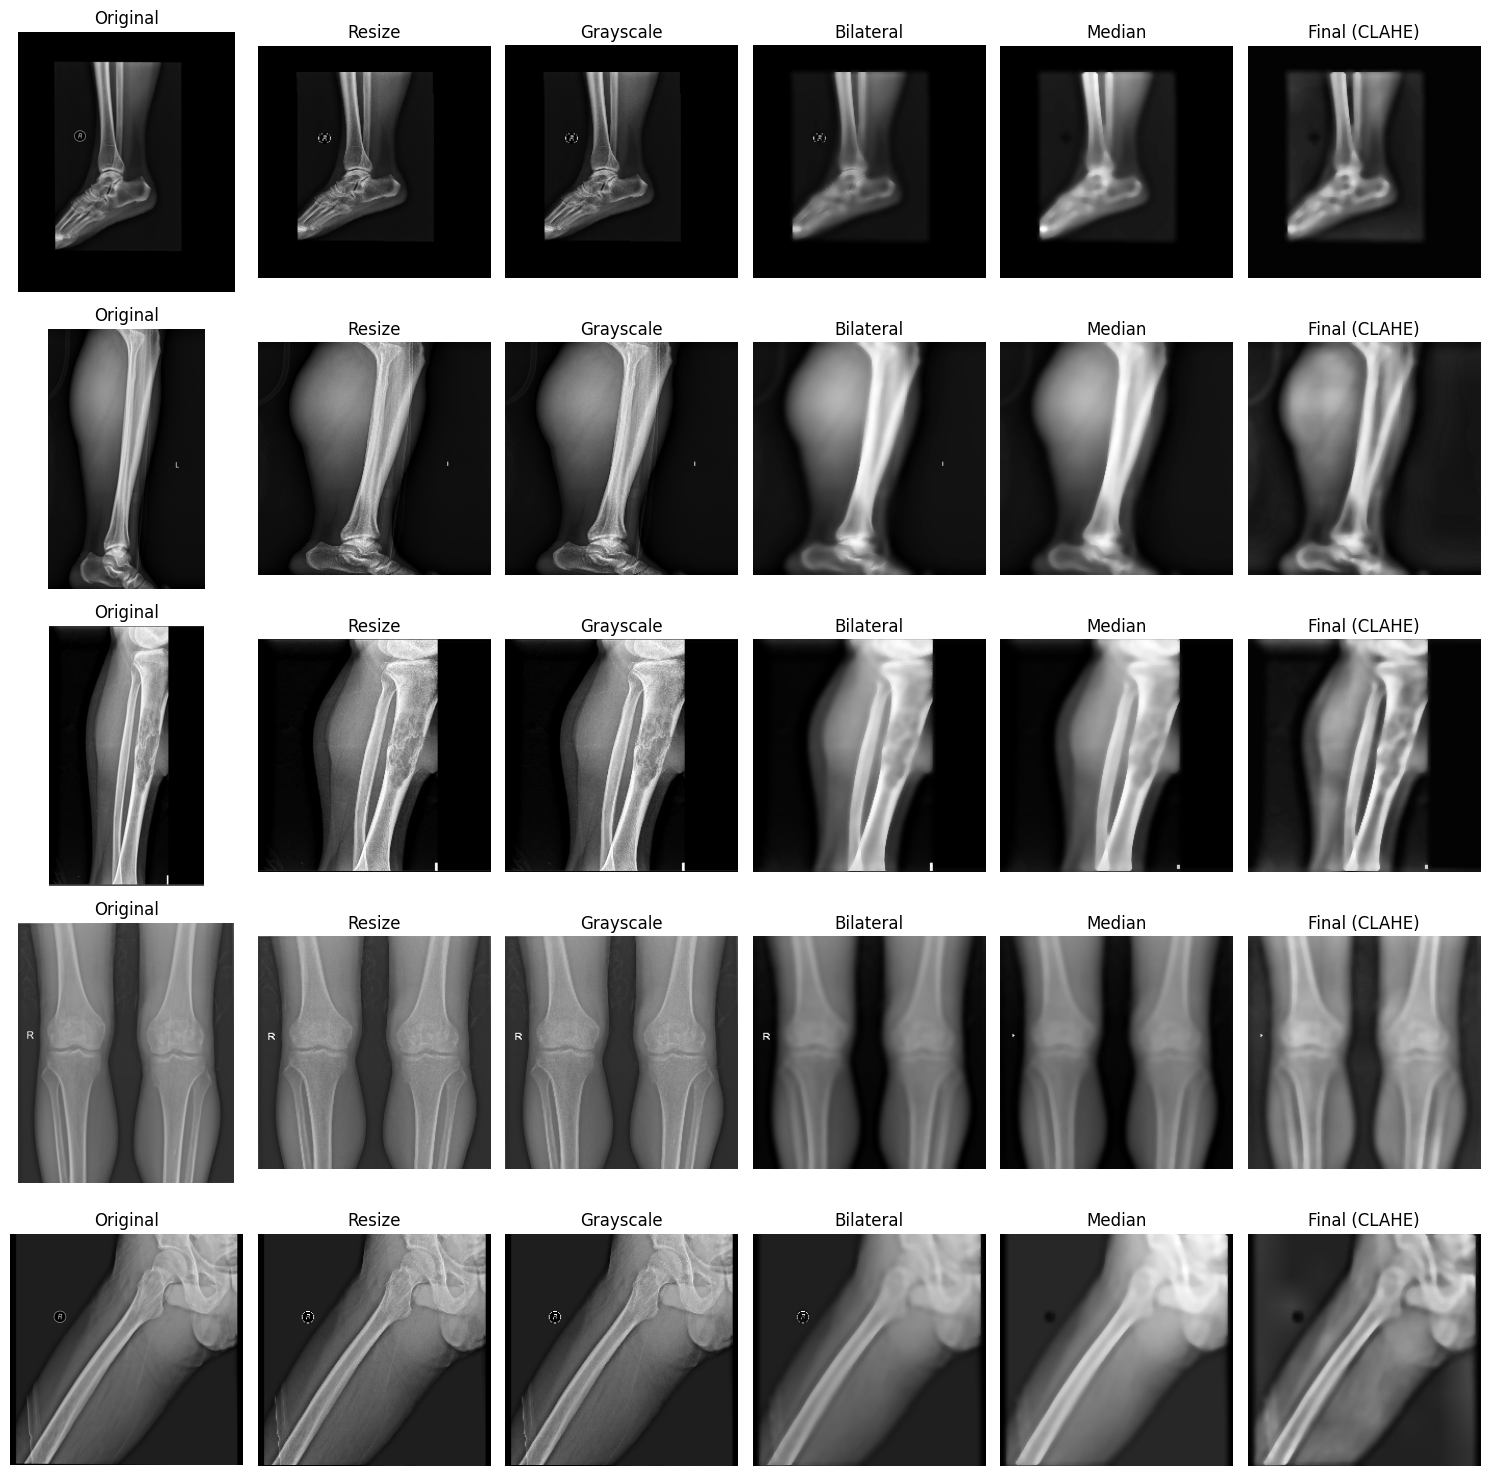


Batch info:
Train: 61
Val  : 8
Test : 8


I0000 00:00:1781313355.664928      22 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13757 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1781313355.671158      22 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13757 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/50


...

48/61 ━━━━━━━━━━━━━━━━━━━━ 13s 1s/step - accuracy: 0.3945 - loss: 1.4942

2026-06-13 01:17:18.746134: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-06-13 01:17:18.882742: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


61/61 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.3897 - loss: 1.4651

2026-06-13 01:17:53.150193: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-06-13 01:17:53.303941: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-06-13 01:17:53.440218: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


61/61 ━━━━━━━━━━━━━━━━━━━━ 116s 2s/step - accuracy: 0.3895 - loss: 1.4630 - val_accuracy: 0.4730 - val_loss: 1.0497 - learning_rate: 5.0000e-05
Epoch 2/50
61/61 ━━━━━━━━━━━━━━━━━━━━ 58s 946ms/step - accuracy: 0.4424 - loss: 1.1532 - val_accuracy: 0.4855 - val_loss: 0.9925 - learning_rate: 5.0000e-05
Epoch 3/50
61/61 ━━━━━━━━━━━━━━━━━━━━ 56s 918ms/step - accuracy: 0.4466 - loss: 1.1116 - val_accuracy: 0.5353 - val_loss: 0.9681 - learning_rate: 5.0000e-05
Epoch 4/50
61/61 ━━━━━━━━━━━━━━━━━━━━ 56s 921ms/step - accuracy: 0.5088 - loss: 0.9601 - val_accuracy: 0.5685 - val_loss: 0.9246 - learning_rate: 5.0000e-05
Epoch 5/50
61/61 ━━━━━━━━━━━━━━━━━━━━ 56s 915ms/step - accuracy: 0.5056 - loss: 0.9441 - val_accuracy: 0.5685 - val_loss: 0.9400 - learning_rate: 5.0000e-05
Epoch 6/50
61/61 ━━━━━━━━━━━━━━━━━━━━ 56s 916ms/step - accuracy: 0.5630 - loss: 0.8926 - val_accuracy: 0.5768 - val_loss: 0.9082 - learning_rate: 1.5000e-05
Epoch 7/50
61/61 ━━━━━━━━━━━━━━━━━━━━ 57s 938ms/step - accuracy: 0.5325

In [6]:
# =========================================
# FINAL PIPELINE: PREVIEW + AUGMENT + OPTIMIZED MODEL
# =========================================

import cv2
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
import math

from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout
from tensorflow.keras.models import Model
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

from sklearn.metrics import classification_report, accuracy_score
from sklearn.utils.class_weight import compute_class_weight

print("Mulai pipeline FINAL...")

# =========================================
# PREPROCESS FUNCTION (FILTER_CLAHE)
# =========================================

def preprocess_image(img):
    img = cv2.resize(img, (224,224))
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

    bilateral = cv2.bilateralFilter(gray, 9, 75, 75)
    median = cv2.medianBlur(bilateral, 5)

    clahe = cv2.createCLAHE(2.0, (8,8))
    processed = clahe.apply(median)

    processed = cv2.cvtColor(processed, cv2.COLOR_GRAY2RGB)
    return processed / 255.0


# =========================================
# VISUALISASI PREPROCESS (DEBUG)
# =========================================

def show_preprocessing_sample(df, n=3):
    print("\nMenampilkan semua tahap preprocessing...")

    fig, axes = plt.subplots(n, 6, figsize=(15, 3*n))

    for i in range(n):
        row = df.sample(1).iloc[0]
        img = cv2.imread(row["image_path"])

        if img is None:
            continue

        # STEP 1
        resized = cv2.resize(img, (224,224))

        # STEP 2
        gray = cv2.cvtColor(resized, cv2.COLOR_BGR2GRAY)

        # STEP 3
        bilateral = cv2.bilateralFilter(gray, 9, 75, 75)

        # STEP 4
        median = cv2.medianBlur(bilateral, 5)

        # STEP 5
        clahe = cv2.createCLAHE(2.0, (8,8))
        clahe_img = clahe.apply(median)

        # STEP 6
        final = cv2.cvtColor(clahe_img, cv2.COLOR_GRAY2RGB) / 255.0

        images = [
            cv2.cvtColor(img, cv2.COLOR_BGR2RGB),
            resized,
            gray,
            bilateral,
            median,
            final
        ]

        titles = [
            "Original",
            "Resize",
            "Grayscale",
            "Bilateral",
            "Median",
            "Final (CLAHE)"
        ]

        for j in range(6):
            axes[i,j].imshow(images[j], cmap="gray" if j>=2 else None)
            axes[i,j].set_title(titles[j])
            axes[i,j].axis("off")

    plt.tight_layout()
    plt.show()
    
# =========================================
# GENERATOR (AUGMENT LEBIH KUAT)
# =========================================

class CustomGenerator(tf.keras.utils.Sequence):
    def __init__(self, df, batch_size, shuffle=True):
        self.df = df.reset_index(drop=True)
        self.batch_size = batch_size
        self.shuffle = shuffle
        self.indexes = np.arange(len(df))
        self.labels = sorted(df["label"].unique())
        self.label_map = {k:i for i,k in enumerate(self.labels)}

    def __len__(self):
        return math.ceil(len(self.df) / self.batch_size)

    def __getitem__(self, idx):
        batch_idx = self.indexes[idx*self.batch_size:(idx+1)*self.batch_size]
        batch = self.df.iloc[batch_idx]

        X, y = [], []

        for _, row in batch.iterrows():
            img = cv2.imread(row["image_path"])
            if img is None:
                continue

            img = preprocess_image(img)

            # =================================
            # AUGMENTASI LEBIH KUAT (TRAIN ONLY)
            # =================================
            if self.shuffle:
                if np.random.rand() < 0.5:
                    img = np.fliplr(img)

                if np.random.rand() < 0.3:
                    img = np.rot90(img)

                if np.random.rand() < 0.3:
                    noise = np.random.normal(0, 0.02, img.shape)
                    img = np.clip(img + noise, 0, 1)

                if np.random.rand() < 0.3:
                    img = np.clip(img * (0.8 + 0.4*np.random.rand()), 0, 1)

            X.append(img)
            y.append(self.label_map[row["label"]])

        return np.array(X), tf.keras.utils.to_categorical(y, num_classes=len(self.labels))

    def on_epoch_end(self):
        if self.shuffle:
            np.random.shuffle(self.indexes)


# =========================================
# MODEL OPTIMIZED
# =========================================

def build_model(num_classes):
    base_model = MobileNetV2(weights="imagenet", include_top=False, input_shape=(224,224,3))

    # freeze lebih banyak
    for layer in base_model.layers[:-5]:
        layer.trainable = False

    for layer in base_model.layers[-5:]:
        layer.trainable = True

    x = base_model.output
    x = GlobalAveragePooling2D()(x)

    x = Dense(128, activation="relu")(x)
    x = Dropout(0.6)(x)

    output = Dense(num_classes, activation="softmax")(x)

    model = Model(inputs=base_model.input, outputs=output)

    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=5e-5),
        loss="categorical_crossentropy",
        metrics=["accuracy"]
    )

    return model


# =========================================
# CLASS WEIGHT
# =========================================

labels = train_df["label"]

class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(labels),
    y=labels
)

class_weight_dict = dict(zip(range(len(class_weights)), class_weights))

print("Class weight:", class_weight_dict)


# =========================================
# CALLBACK
# =========================================

early_stop = EarlyStopping(monitor="val_loss", patience=2, restore_best_weights=True)
reduce_lr = ReduceLROnPlateau(monitor="val_loss", factor=0.3, patience=1)


# =========================================
# PREVIEW HASIL PREPROCESS
# =========================================

show_preprocessing_sample(train_df, n=5)


# =========================================
# GENERATOR
# =========================================

train_gen = CustomGenerator(train_df, 32, shuffle=True)
val_gen = CustomGenerator(val_df, 32, shuffle=False)
test_gen = CustomGenerator(test_df, 32, shuffle=False)

print("\nBatch info:")
print("Train:", len(train_gen))
print("Val  :", len(val_gen))
print("Test :", len(test_gen))


# =========================================
# TRAINING FINAL
# =========================================

model = build_model(num_classes=len(train_gen.labels))

history = model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=50,
    class_weight=class_weight_dict,
    callbacks=[early_stop, reduce_lr],
    verbose=1
)


# =========================================
# EVALUASI
# =========================================

y_pred, y_true = [], []

for i in range(len(test_gen)):
    X, y = test_gen[i]

    if len(X) == 0:
        continue

    pred = model.predict(X, verbose=0)

    y_pred.extend(np.argmax(pred, axis=1))
    y_true.extend(np.argmax(y, axis=1))

print("\nAccuracy:", accuracy_score(y_true, y_pred))
print(classification_report(y_true, y_pred))

Mulai pipeline FINAL...
Class weight: {0: np.float64(0.7422839506172839), 1: np.float64(3.4855072463768115), 2: np.float64(0.7321156773211568)}

Menampilkan semua tahap preprocessing...


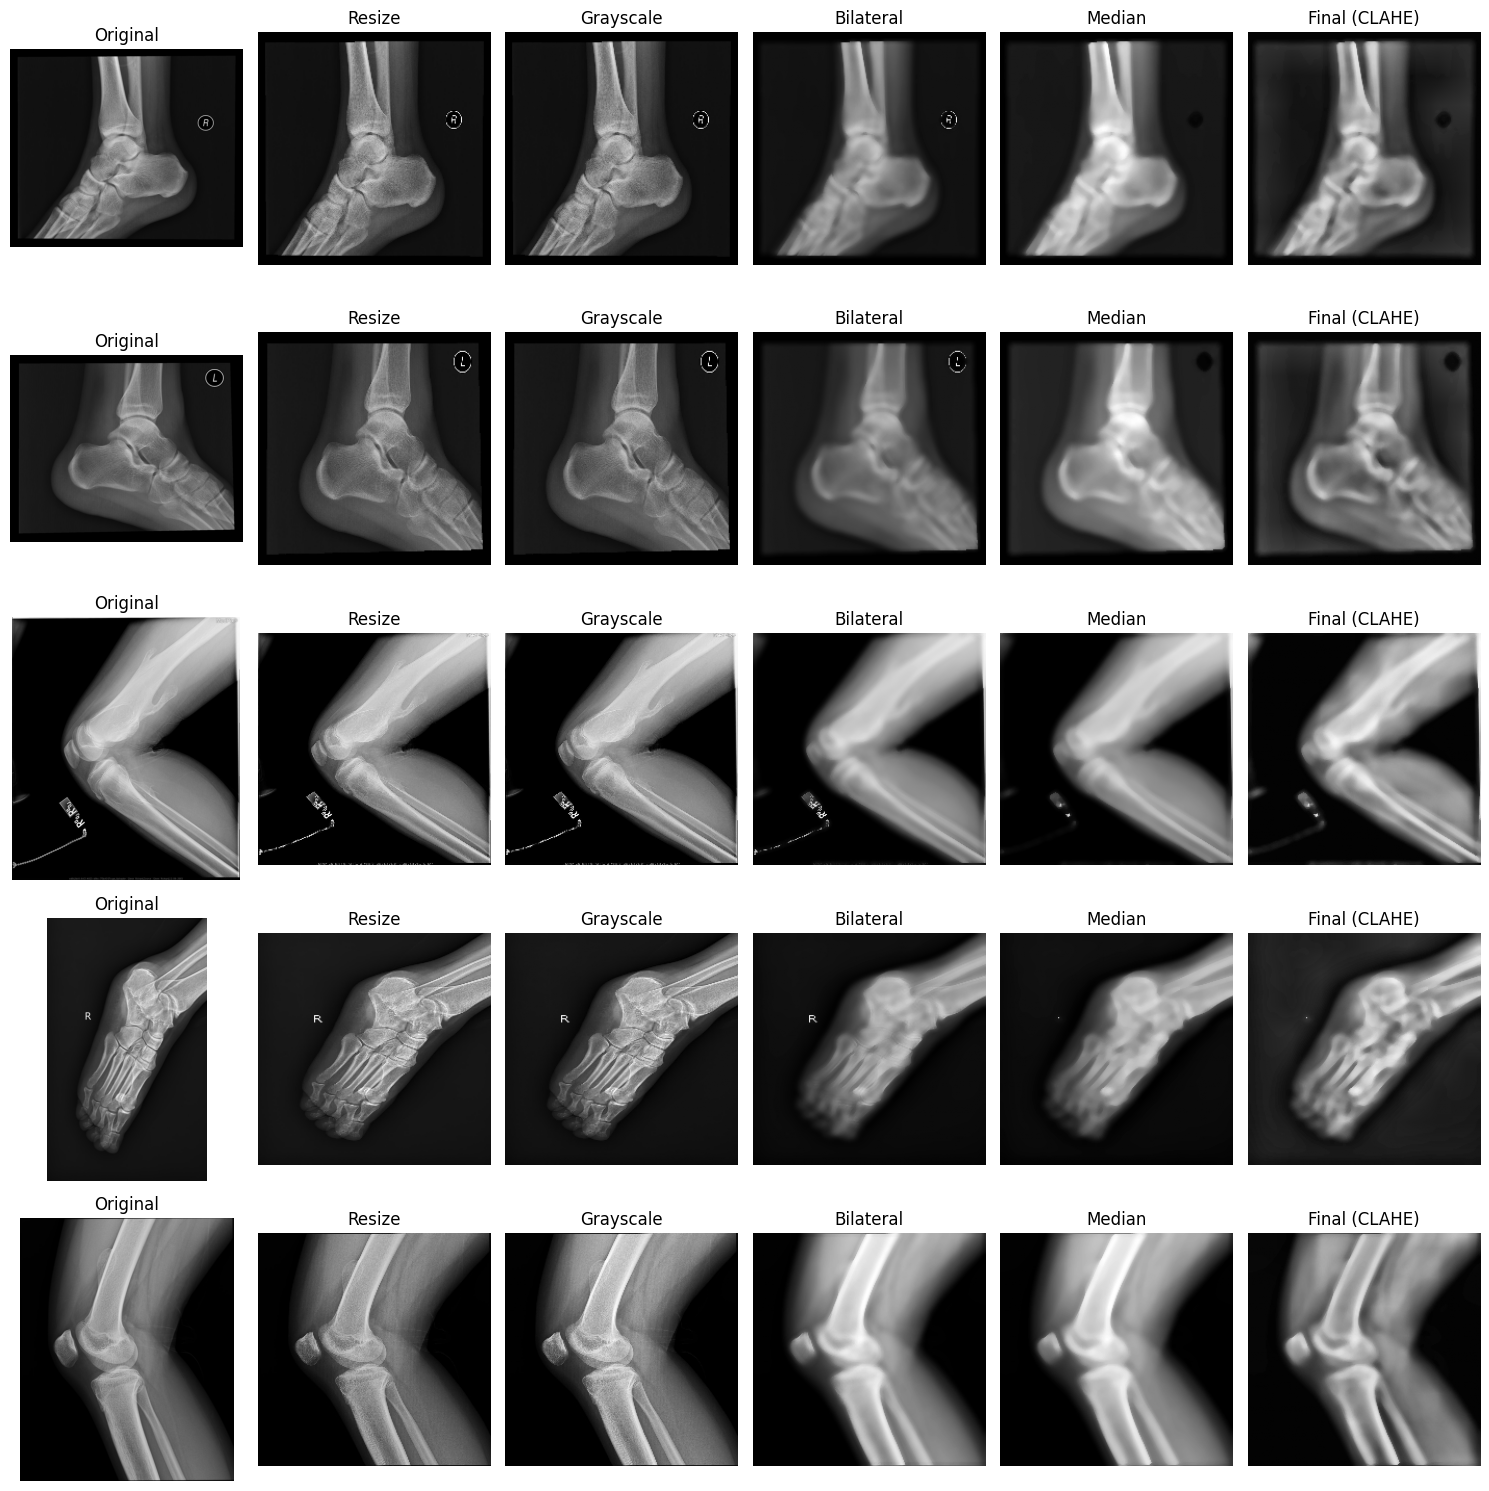


Batch info:
Train: 61
Val  : 8
Test : 8


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/50
61/61 ━━━━━━━━━━━━━━━━━━━━ 86s 1s/step - accuracy: 0.3978 - loss: 1.5493 - val_accuracy: 0.4896 - val_loss: 0.9995 - learning_rate: 5.0000e-05
Epoch 2/50
61/61 ━━━━━━━━━━━━━━━━━━━━ 57s 939ms/step - accuracy: 0.4502 - loss: 1.1638 - val_accuracy: 0.5270 - val_loss: 0.9512 - learning_rate: 5.0000e-05
Epoch 3/50
61/61 ━━━━━━━━━━━━━━━━━━━━ 55s 910ms/step - accuracy: 0.5157 - loss: 0.9507 - val_accuracy: 0.5270 - val_loss: 0.9161 - learning_rate: 5.0000e-05
Epoch 4/50
61/61 ━━━━━━━━━━━━━━━━━━━━ 59s 963ms/step - accuracy: 0.5308 - loss: 0.9222 - val_accuracy: 0.5768 - val_loss: 0.8858 - learning_rate: 5.0000e-05
Epoch 5/50
61/61 ━━━━━━━━━━━━━━━━━━━━ 55s 900ms/step - accuracy: 0.5660 - loss: 0.8502 - val_accuracy: 0.6017 - val_loss: 0.8542 - learning_rate: 5.0000e-05
Epoch 6/50
61/61 ━━━━━━━━━━━━━━━━━━━━ 56s 914ms/step - accuracy: 0.6047 - loss: 0.7734 - val_accuracy: 0.5975 - val_loss: 0.8469 - learning_rate: 5.0000e-05
Epoch 7/50
61/61 ━━━━━━━━━━━━━━━━━━━━ 55s 904ms/step - accura

In [7]:
# =========================================
# FINAL PIPELINE: PREVIEW + AUGMENT + OPTIMIZED MODEL
# =========================================

import cv2
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
import math

from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout
from tensorflow.keras.models import Model
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

from sklearn.metrics import classification_report, accuracy_score
from sklearn.utils.class_weight import compute_class_weight

print("Mulai pipeline FINAL...")

# =========================================
# PREPROCESS FUNCTION (FILTER_CLAHE)
# =========================================

def preprocess_image(img):
    img = cv2.resize(img, (224,224))
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

    bilateral = cv2.bilateralFilter(gray, 9, 75, 75)
    median = cv2.medianBlur(bilateral, 5)

    clahe = cv2.createCLAHE(2.0, (8,8))
    processed = clahe.apply(median)

    processed = cv2.cvtColor(processed, cv2.COLOR_GRAY2RGB)
    return processed / 255.0


# =========================================
# VISUALISASI PREPROCESS (DEBUG)
# =========================================

def show_preprocessing_sample(df, n=3):
    print("\nMenampilkan semua tahap preprocessing...")

    fig, axes = plt.subplots(n, 6, figsize=(15, 3*n))

    for i in range(n):
        row = df.sample(1).iloc[0]
        img = cv2.imread(row["image_path"])

        if img is None:
            continue

        # STEP 1
        resized = cv2.resize(img, (224,224))

        # STEP 2
        gray = cv2.cvtColor(resized, cv2.COLOR_BGR2GRAY)

        # STEP 3
        bilateral = cv2.bilateralFilter(gray, 9, 75, 75)

        # STEP 4
        median = cv2.medianBlur(bilateral, 5)

        # STEP 5
        clahe = cv2.createCLAHE(2.0, (8,8))
        clahe_img = clahe.apply(median)

        # STEP 6
        final = cv2.cvtColor(clahe_img, cv2.COLOR_GRAY2RGB) / 255.0

        images = [
            cv2.cvtColor(img, cv2.COLOR_BGR2RGB),
            resized,
            gray,
            bilateral,
            median,
            final
        ]

        titles = [
            "Original",
            "Resize",
            "Grayscale",
            "Bilateral",
            "Median",
            "Final (CLAHE)"
        ]

        for j in range(6):
            axes[i,j].imshow(images[j], cmap="gray" if j>=2 else None)
            axes[i,j].set_title(titles[j])
            axes[i,j].axis("off")

    plt.tight_layout()
    plt.show()
    
# =========================================
# GENERATOR (AUGMENT LEBIH KUAT)
# =========================================

class CustomGenerator(tf.keras.utils.Sequence):
    def __init__(self, df, batch_size, shuffle=True):
        self.df = df.reset_index(drop=True)
        self.batch_size = batch_size
        self.shuffle = shuffle
        self.indexes = np.arange(len(df))
        self.labels = sorted(df["label"].unique())
        self.label_map = {k:i for i,k in enumerate(self.labels)}

    def __len__(self):
        return math.ceil(len(self.df) / self.batch_size)

    def __getitem__(self, idx):
        batch_idx = self.indexes[idx*self.batch_size:(idx+1)*self.batch_size]
        batch = self.df.iloc[batch_idx]

        X, y = [], []

        for _, row in batch.iterrows():
            img = cv2.imread(row["image_path"])
            if img is None:
                continue

            img = preprocess_image(img)

            # =================================
            # AUGMENTASI LEBIH KUAT (TRAIN ONLY)
            # =================================
            if self.shuffle:
                if np.random.rand() < 0.5:
                    img = np.fliplr(img)

                if np.random.rand() < 0.3:
                    img = np.rot90(img)

                if np.random.rand() < 0.3:
                    noise = np.random.normal(0, 0.02, img.shape)
                    img = np.clip(img + noise, 0, 1)

                if np.random.rand() < 0.3:
                    img = np.clip(img * (0.8 + 0.4*np.random.rand()), 0, 1)

            X.append(img)
            y.append(self.label_map[row["label"]])

        return np.array(X), tf.keras.utils.to_categorical(y, num_classes=len(self.labels))

    def on_epoch_end(self):
        if self.shuffle:
            np.random.shuffle(self.indexes)


# =========================================
# MODEL OPTIMIZED
# =========================================

def build_model(num_classes):
    base_model = MobileNetV2(weights="imagenet", include_top=False, input_shape=(224,224,3))

    # freeze lebih banyak
    for layer in base_model.layers[:-5]:
        layer.trainable = False

    for layer in base_model.layers[:-30]:
        layer.trainable = False
    for layer in base_model.layers[-30:]:
        layer.trainable = True

    x = base_model.output
    x = GlobalAveragePooling2D()(x)

    x = Dense(128, activation="relu")(x)
    x = Dropout(0.6)(x)

    output = Dense(num_classes, activation="softmax")(x)

    model = Model(inputs=base_model.input, outputs=output)

    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=5e-5),
        loss="categorical_crossentropy",
        metrics=["accuracy"]
    )

    return model


# =========================================
# CLASS WEIGHT
# =========================================

labels = train_df["label"]

class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(labels),
    y=labels
)

class_weight_dict = dict(zip(range(len(class_weights)), class_weights))

print("Class weight:", class_weight_dict)


# =========================================
# CALLBACK
# =========================================

early_stop = EarlyStopping(monitor="val_loss", patience=2, restore_best_weights=True)
reduce_lr = ReduceLROnPlateau(monitor="val_loss", factor=0.3, patience=1)


# =========================================
# PREVIEW HASIL PREPROCESS
# =========================================

show_preprocessing_sample(train_df, n=5)


# =========================================
# GENERATOR
# =========================================

train_gen = CustomGenerator(train_df, 32, shuffle=True)
val_gen = CustomGenerator(val_df, 32, shuffle=False)
test_gen = CustomGenerator(test_df, 32, shuffle=False)

print("\nBatch info:")
print("Train:", len(train_gen))
print("Val  :", len(val_gen))
print("Test :", len(test_gen))


# =========================================
# TRAINING FINAL
# =========================================

model = build_model(num_classes=len(train_gen.labels))

history = model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=50,
    class_weight=class_weight_dict,
    callbacks=[early_stop, reduce_lr],
    verbose=1
)


# =========================================
# EVALUASI
# =========================================

y_pred, y_true = [], []

for i in range(len(test_gen)):
    X, y = test_gen[i]

    if len(X) == 0:
        continue

    pred = model.predict(X, verbose=0)

    y_pred.extend(np.argmax(pred, axis=1))
    y_true.extend(np.argmax(y, axis=1))

print("\nAccuracy:", accuracy_score(y_true, y_pred))
print(classification_report(y_true, y_pred))


FULL PREDICTION TABLE — ALL SAMPLES
       actual  predicted  confidence  correct  prob_benign  prob_malignant  \
0      benign     benign    0.339635     True     0.339635        0.325252   
1   malignant     benign    0.411253    False     0.411253        0.325273   
2   malignant  malignant    0.438647     True     0.291355        0.438647   
3      benign     normal    0.450602    False     0.403996        0.145402   
4      normal     benign    0.451304    False     0.451304        0.171110   
5   malignant  malignant    0.457491     True     0.256769        0.457491   
6      benign  malignant    0.457940    False     0.429310        0.457940   
7   malignant  malignant    0.463554     True     0.233187        0.463554   
8      benign     benign    0.465426     True     0.465426        0.092654   
9      normal     benign    0.467737    False     0.467737        0.230354   
10  malignant     normal    0.468156    False     0.218486        0.313357   
11     benign     benign   

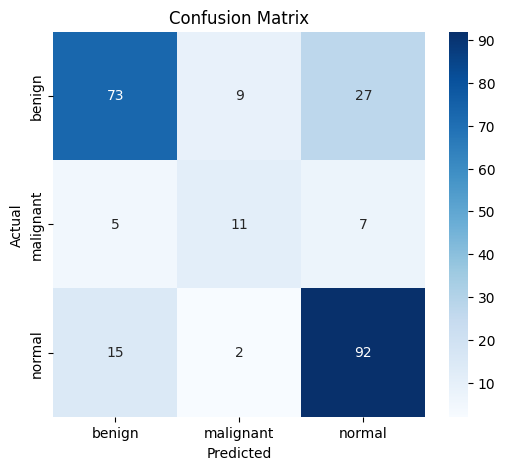

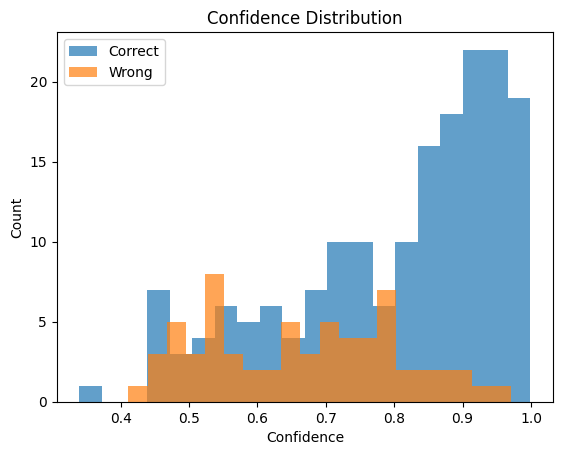

In [8]:
# =========================================
# FULL PREDICTION TABLE + ANALYSIS
# =========================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import cv2

from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

print("\n" + "="*70)
print("FULL PREDICTION TABLE — ALL SAMPLES")
print("="*70)

# =========================================
# LABEL MAPPING
# =========================================

label_names = train_gen.labels
idx_to_label = {i:label for i,label in enumerate(label_names)}

# =========================================
# BUILD PREDICTION TABLE
# =========================================

records = []

for i in range(len(test_gen)):
    X, y = test_gen[i]

    if len(X) == 0:
        continue

    preds = model.predict(X, verbose=0)

    for j in range(len(X)):
        true_idx = np.argmax(y[j])
        pred_idx = np.argmax(preds[j])

        record = {
            "image_path": test_df.iloc[i*test_gen.batch_size + j]["image_path"],
            "actual": idx_to_label[true_idx],
            "predicted": idx_to_label[pred_idx],
            "confidence": float(np.max(preds[j])),
            "correct": true_idx == pred_idx
        }

        # simpan probabilitas tiap kelas
        for k in range(len(label_names)):
            record[f"prob_{idx_to_label[k]}"] = float(preds[j][k])

        records.append(record)

pred_df = pd.DataFrame(records)

# =========================================
# SORT BY UNCERTAINTY (LOW CONFIDENCE)
# =========================================

pred_df = pred_df.sort_values("confidence", ascending=True).reset_index(drop=True)

# =========================================
# PRINT TABLE
# =========================================

display_df = pred_df[[
    "actual", "predicted", "confidence", "correct"
] + [col for col in pred_df.columns if "prob_" in col]]

print(display_df.head(30))  # tampilkan 30 teratas (paling susah)

# =========================================
# SUMMARY
# =========================================

acc = accuracy_score(pred_df["actual"], pred_df["predicted"])

print("\n" + "-"*50)
print(f"Total data     : {len(pred_df)}")
print(f"Accuracy       : {acc:.4f}")
print(f"Correct        : {pred_df['correct'].sum()}")
print(f"Wrong          : {(~pred_df['correct']).sum()}")

print("\nClassification Report:")
print(classification_report(pred_df["actual"], pred_df["predicted"]))

# =========================================
# CONFUSION MATRIX
# =========================================

plt.figure(figsize=(6,5))
cm = confusion_matrix(pred_df["actual"], pred_df["predicted"], labels=label_names)

sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=label_names,
            yticklabels=label_names)

plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# =========================================
# CONFIDENCE DISTRIBUTION
# =========================================

plt.figure()
plt.hist(pred_df[pred_df["correct"]]["confidence"], bins=20, alpha=0.7, label="Correct")
plt.hist(pred_df[~pred_df["correct"]]["confidence"], bins=20, alpha=0.7, label="Wrong")
plt.legend()
plt.title("Confidence Distribution")
plt.xlabel("Confidence")
plt.ylabel("Count")
plt.show()

In [9]:
pred_df.to_csv("baseline_predictions.csv", index=False)

print("Baseline disimpan.")

Baseline disimpan.


In [10]:
from sklearn.metrics import classification_report

report = classification_report(
    pred_df["actual"],
    pred_df["predicted"],
    output_dict=True
)

report_df = pd.DataFrame(report).transpose()
report_df.to_csv("baseline_report.csv")

report_df

,precision,recall,f1-score,support
benign,0.784946,0.669725,0.722772,109.00000
malignant,0.500000,0.478261,0.488889,23.00000
normal,0.730159,0.844037,0.782979,109.00000
accuracy,0.730290,0.730290,0.730290,0.73029
macro avg,0.671702,0.664007,0.664880,241.00000
weighted avg,0.732973,0.730290,0.727682,241.00000


In [11]:
tp_malignant = pred_df[
    (pred_df["actual"]=="malignant") &
    (pred_df["predicted"]=="malignant")
].head(5)

fn_malignant = pred_df[
    (pred_df["actual"]=="malignant") &
    (pred_df["predicted"]!="malignant")
].head(5)

print("TP:", len(tp_malignant))
print("FN:", len(fn_malignant))

TP: 5
FN: 5


In [12]:
def get_last_conv_layer(model):
    """
    Mengambil nama layer Conv2D terakhir secara otomatis.
    """
    for layer in reversed(model.layers):
        if isinstance(layer, tf.keras.layers.Conv2D):
            return layer.name

    raise ValueError("Tidak ditemukan Conv2D layer.")

In [13]:
LAST_CONV_LAYER = get_last_conv_layer(model)

print("Last Conv Layer:", LAST_CONV_LAYER)

Last Conv Layer: Conv_1


In [14]:
tp_malignant = pred_df[
    (pred_df["actual"]=="malignant") &
    (pred_df["predicted"]=="malignant")
].head(5)

tp_malignant

,image_path,actual,predicted,confidence,correct,prob_benign,prob_malignant,prob_normal
2,/kaggle/input/datasets/adityajanjiree/bone-can...,malignant,malignant,0.438647,True,0.291355,0.438647,0.269999
5,/kaggle/input/datasets/adityajanjiree/bone-can...,malignant,malignant,0.457491,True,0.256769,0.457491,0.285740
7,/kaggle/input/datasets/adityajanjiree/bone-can...,malignant,malignant,0.463554,True,0.233187,0.463554,0.303260
12,/kaggle/input/datasets/adityajanjiree/bone-can...,malignant,malignant,0.469865,True,0.380579,0.469865,0.149557
26,/kaggle/input/datasets/adityajanjiree/bone-can...,malignant,malignant,0.528837,True,0.314504,0.528837,0.156659


In [15]:
fn_malignant = pred_df[
    (pred_df["actual"]=="malignant") &
    (pred_df["predicted"]!="malignant")
].head(5)

fn_malignant

,image_path,actual,predicted,confidence,correct,prob_benign,prob_malignant,prob_normal
1,/kaggle/input/datasets/adityajanjiree/bone-can...,malignant,benign,0.411253,False,0.411253,0.325273,0.263474
10,/kaggle/input/datasets/adityajanjiree/bone-can...,malignant,normal,0.468156,False,0.218486,0.313357,0.468156
15,/kaggle/input/datasets/adityajanjiree/bone-can...,malignant,normal,0.483199,False,0.478342,0.038458,0.483199
28,/kaggle/input/datasets/adityajanjiree/bone-can...,malignant,benign,0.536653,False,0.536653,0.039814,0.423533
57,/kaggle/input/datasets/adityajanjiree/bone-can...,malignant,normal,0.624180,False,0.330997,0.044822,0.624180


In [16]:
def make_gradcam_heatmap(img_array,
                         model,
                         last_conv_layer_name,
                         pred_index=None):

    grad_model = tf.keras.models.Model(
        inputs=model.inputs,
        outputs=[
            model.get_layer(last_conv_layer_name).output,
            model.output
        ]
    )

    with tf.GradientTape() as tape:

        conv_outputs, predictions = grad_model(img_array)

        if pred_index is None:
            pred_index = tf.argmax(predictions[0])

        class_channel = predictions[:, pred_index]

    grads = tape.gradient(class_channel,
                          conv_outputs)

    pooled_grads = tf.reduce_mean(
        grads,
        axis=(0,1,2)
    )

    conv_outputs = conv_outputs[0]

    heatmap = conv_outputs @ pooled_grads[..., tf.newaxis]

    heatmap = tf.squeeze(heatmap)

    heatmap = tf.maximum(heatmap, 0)

    heatmap /= tf.reduce_max(heatmap) + 1e-8

    return heatmap.numpy()

In [17]:
def show_gradcam(df_samples,
                 title,
                 model):

    last_conv = get_last_conv_layer(model)

    plt.figure(figsize=(15,6))

    for i, (_, row) in enumerate(df_samples.iterrows()):

        img = cv2.imread(row["image_path"])

        img_pre = preprocess_image(img)

        img_array = np.expand_dims(img_pre,
                                   axis=0)

        heatmap = make_gradcam_heatmap(
            img_array,
            model,
            last_conv
        )

        heatmap = cv2.resize(
            heatmap,
            (224,224)
        )

        original = cv2.cvtColor(
            cv2.resize(img,(224,224)),
            cv2.COLOR_BGR2RGB
        )

        plt.subplot(2,5,i+1)

        plt.imshow(original)

        plt.imshow(
            heatmap,
            cmap='jet',
            alpha=0.4
        )

        plt.title(
            f"A:{row['actual']}\nP:{row['predicted']}"
        )

        plt.axis("off")

    plt.suptitle(title)

    plt.show()

/usr/local/lib/python3.12/dist-packages/keras/src/models/functional.py:241: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: ['keras_tensor_158']
Received: inputs=Tensor(shape=(1, 224, 224, 3))
  warnings.warn(msg)


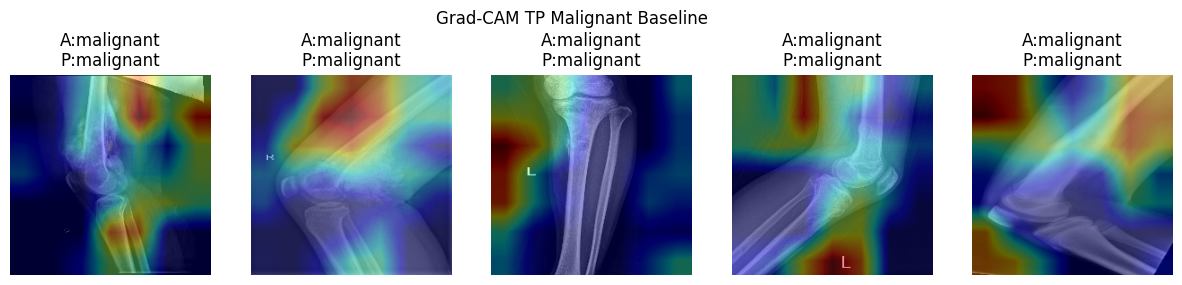

In [18]:
show_gradcam(
    tp_malignant,
    "Grad-CAM TP Malignant Baseline",
    model
)

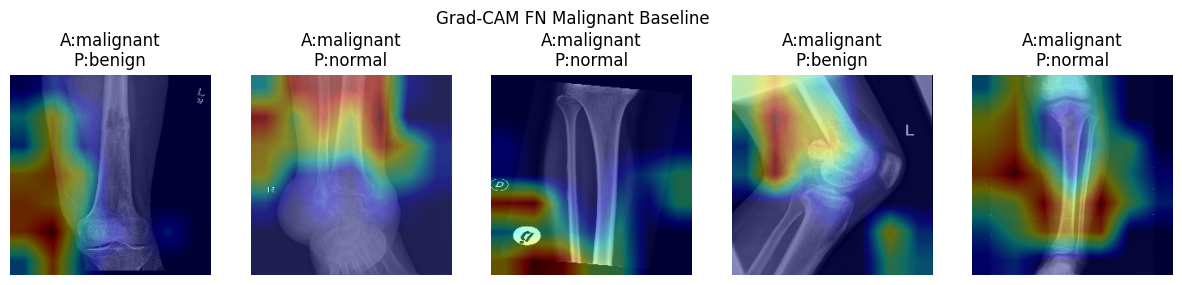

In [19]:
show_gradcam(
    fn_malignant,
    "Grad-CAM FN Malignant Baseline",
    model
)

In [20]:
from tensorflow.keras.layers import (
    GlobalMaxPooling2D,
    Reshape,
    Multiply,
    Add,
    Activation,
    Concatenate,
    Lambda,
    Conv2D
)

import tensorflow.keras.backend as K

In [21]:
def channel_attention(input_feature,
                      ratio=8):

    channel = input_feature.shape[-1]

    shared_dense_one = Dense(
        channel//ratio,
        activation='relu'
    )

    shared_dense_two = Dense(channel)

    avg_pool = GlobalAveragePooling2D()(
        input_feature
    )

    avg_pool = Reshape((1,1,channel))(
        avg_pool
    )

    avg_pool = shared_dense_one(avg_pool)

    avg_pool = shared_dense_two(avg_pool)

    max_pool = GlobalMaxPooling2D()(
        input_feature
    )

    max_pool = Reshape((1,1,channel))(
        max_pool
    )

    max_pool = shared_dense_one(max_pool)

    max_pool = shared_dense_two(max_pool)

    cbam = Add()([
        avg_pool,
        max_pool
    ])

    cbam = Activation('sigmoid')(cbam)

    return Multiply()([
        input_feature,
        cbam
    ])

In [22]:
def spatial_attention(input_feature):

    avg_pool = Lambda(
        lambda x: K.mean(
            x,
            axis=3,
            keepdims=True
        )
    )(input_feature)

    max_pool = Lambda(
        lambda x: K.max(
            x,
            axis=3,
            keepdims=True
        )
    )(input_feature)

    concat = Concatenate(axis=3)([
        avg_pool,
        max_pool
    ])

    cbam = Conv2D(
        1,
        kernel_size=7,
        padding='same',
        activation='sigmoid'
    )(concat)

    return Multiply()([
        input_feature,
        cbam
    ])

In [23]:
def cbam_block(feature_map):

    feature_map = channel_attention(
        feature_map
    )

    feature_map = spatial_attention(
        feature_map
    )

    return feature_map

In [24]:
def build_cbam_model(num_classes):

    base_model = MobileNetV2(
        weights='imagenet',
        include_top=False,
        input_shape=(224,224,3)
    )

    for layer in base_model.layers[:-30]:
        layer.trainable = False

    for layer in base_model.layers[-30:]:
        layer.trainable = True

    x = base_model.output

    x = cbam_block(x)

    x = GlobalAveragePooling2D()(x)

    x = Dense(
        128,
        activation='relu'
    )(x)

    x = Dropout(0.6)(x)

    output = Dense(
        num_classes,
        activation='softmax'
    )(x)

    model_cbam = Model(
        base_model.input,
        output
    )

    model_cbam.compile(
        optimizer=tf.keras.optimizers.Adam(
            learning_rate=5e-5
        ),
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )

    return model_cbam

In [25]:
model_cbam = build_cbam_model(
    len(train_gen.labels)
)

history_cbam = model_cbam.fit(
    train_gen,
    validation_data=val_gen,
    epochs=50,
    class_weight=class_weight_dict,
    callbacks=[
        early_stop,
        reduce_lr
    ],
    verbose=1
)

Epoch 1/50
61/61 ━━━━━━━━━━━━━━━━━━━━ 94s 1s/step - accuracy: 0.3878 - loss: 1.1567 - val_accuracy: 0.4813 - val_loss: 1.0024 - learning_rate: 5.0000e-05
Epoch 2/50
61/61 ━━━━━━━━━━━━━━━━━━━━ 56s 925ms/step - accuracy: 0.4306 - loss: 1.0606 - val_accuracy: 0.4979 - val_loss: 0.9672 - learning_rate: 5.0000e-05
Epoch 3/50
61/61 ━━━━━━━━━━━━━━━━━━━━ 57s 932ms/step - accuracy: 0.4929 - loss: 1.0186 - val_accuracy: 0.5062 - val_loss: 0.9360 - learning_rate: 5.0000e-05
Epoch 4/50
61/61 ━━━━━━━━━━━━━━━━━━━━ 56s 917ms/step - accuracy: 0.5389 - loss: 0.9467 - val_accuracy: 0.5892 - val_loss: 0.8888 - learning_rate: 5.0000e-05
Epoch 5/50
61/61 ━━━━━━━━━━━━━━━━━━━━ 57s 939ms/step - accuracy: 0.5870 - loss: 0.8624 - val_accuracy: 0.5602 - val_loss: 0.8803 - learning_rate: 5.0000e-05
Epoch 6/50
61/61 ━━━━━━━━━━━━━━━━━━━━ 56s 920ms/step - accuracy: 0.6273 - loss: 0.7848 - val_accuracy: 0.6058 - val_loss: 0.8351 - learning_rate: 5.0000e-05
Epoch 7/50
61/61 ━━━━━━━━━━━━━━━━━━━━ 56s 936ms/step - accura

In [26]:
y_true = []
y_pred = []

for i in range(len(test_gen)):

    X, y = test_gen[i]

    pred = model_cbam.predict(
        X,
        verbose=0
    )

    y_true.extend(
        np.argmax(y, axis=1)
    )

    y_pred.extend(
        np.argmax(pred, axis=1)
    )

print(
    classification_report(
        y_true,
        y_pred,
        target_names=train_gen.labels
    )
)

              precision    recall  f1-score   support

      benign       0.69      0.79      0.74       109
   malignant       1.00      0.13      0.23        23
      normal       0.77      0.81      0.79       109

    accuracy                           0.73       241
   macro avg       0.82      0.58      0.59       241
weighted avg       0.76      0.73      0.71       241



In [27]:
report_cbam = classification_report(
    y_true,
    y_pred,
    target_names=train_gen.labels,
    output_dict=True
)

pd.DataFrame(report_cbam).transpose()

,precision,recall,f1-score,support
benign,0.693548,0.788991,0.738197,109.00000
malignant,1.000000,0.130435,0.230769,23.00000
normal,0.771930,0.807339,0.789238,109.00000
accuracy,0.734440,0.734440,0.734440,0.73444
macro avg,0.821826,0.575588,0.586068,241.00000
weighted avg,0.758245,0.734440,0.712855,241.00000


/usr/local/lib/python3.12/dist-packages/keras/src/models/functional.py:241: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: ['keras_tensor_316']
Received: inputs=Tensor(shape=(1, 224, 224, 3))
  warnings.warn(msg)


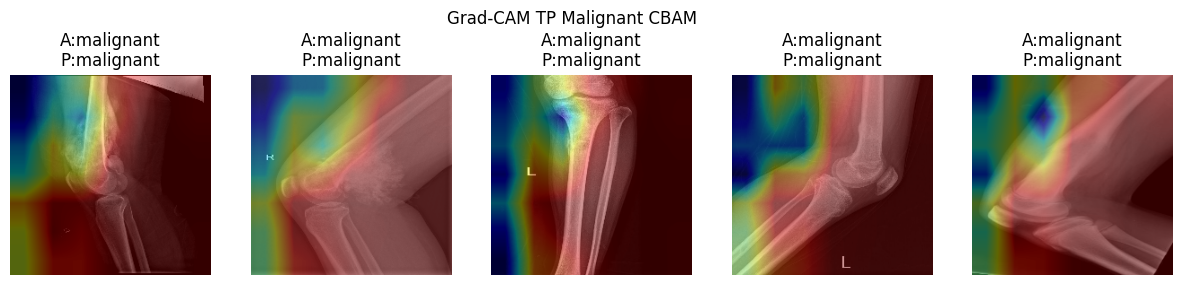

In [28]:
show_gradcam(
    tp_malignant,
    "Grad-CAM TP Malignant CBAM",
    model_cbam
)

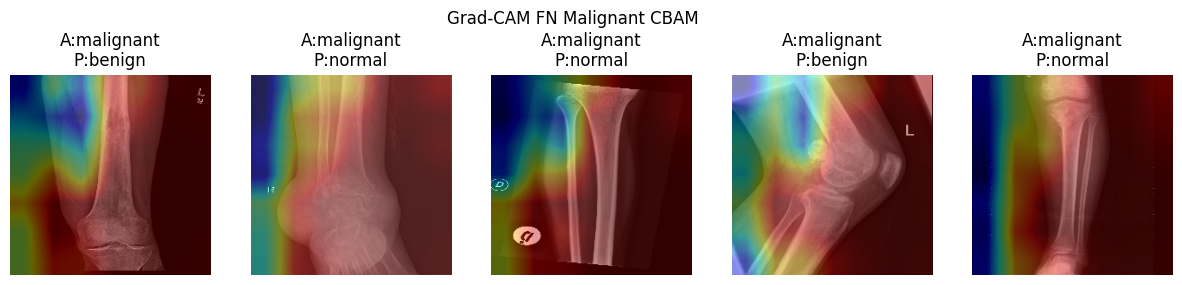

In [29]:
show_gradcam(
    fn_malignant,
    "Grad-CAM FN Malignant CBAM",
    model_cbam
)

In [30]:
!pip install shap -q

In [31]:
import shap

In [32]:
background = []

for i in range(5):
    X, _ = train_gen[i]
    background.extend(X)

background = np.array(background[:50])

print(background.shape)

(50, 224, 224, 3)


In [33]:
shap_samples = pd.concat([
    tp_malignant,
    fn_malignant
]).reset_index(drop=True)

len(shap_samples)

10

In [34]:
X_shap = []

for _, row in shap_samples.iterrows():

    img = cv2.imread(row["image_path"])

    img = preprocess_image(img)

    X_shap.append(img)

X_shap = np.array(X_shap)

print(X_shap.shape)

(10, 224, 224, 3)


In [35]:
explainer_baseline = shap.GradientExplainer(
    model,
    background
)

shap_values_baseline = explainer_baseline.shap_values(
    X_shap
)

/usr/local/lib/python3.12/dist-packages/keras/src/models/functional.py:241: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: keras_tensor_158
Received: inputs=['Tensor(shape=(10, 224, 224, 3))']
  warnings.warn(msg)
/usr/local/lib/python3.12/dist-packages/keras/src/models/functional.py:241: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: keras_tensor_158
Received: inputs=['Tensor(shape=(50, 224, 224, 3))']
  warnings.warn(msg)


In [36]:
malignant_idx = train_gen.label_map["malignant"]

print(malignant_idx)

1


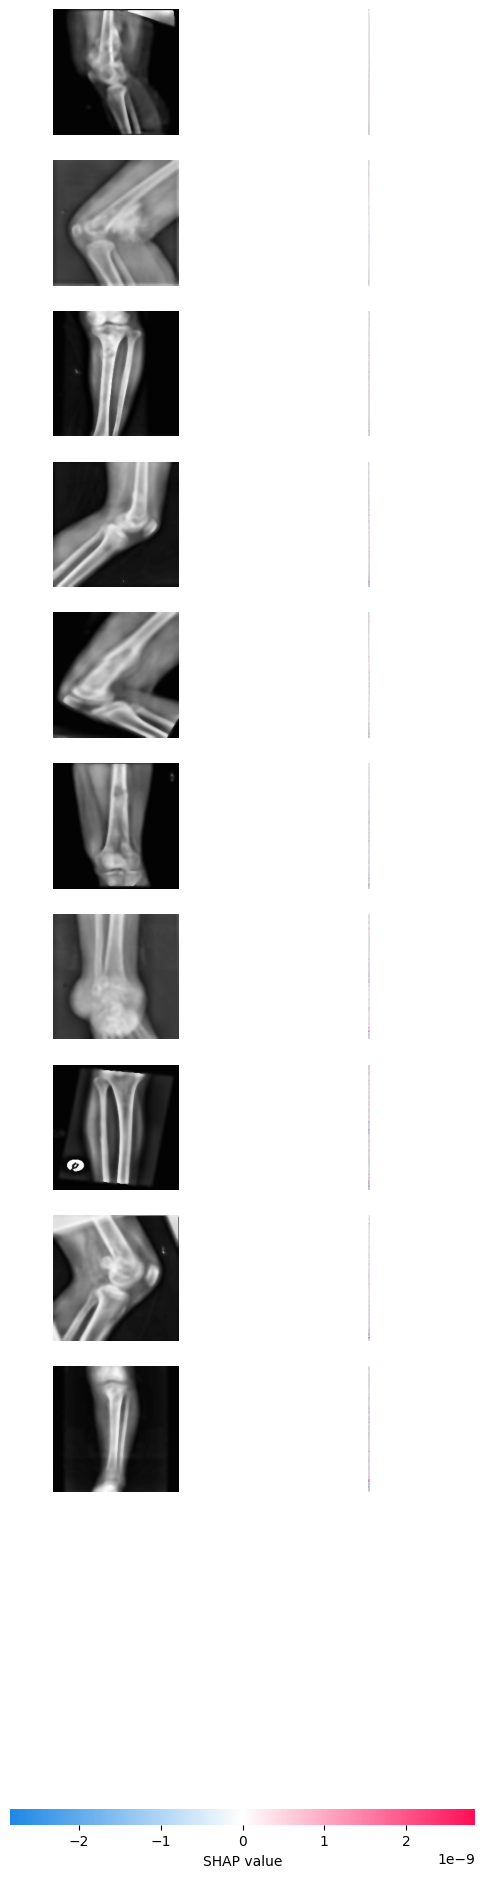

In [37]:
shap.image_plot(
    shap_values_baseline[malignant_idx],
    X_shap
)

In [38]:
explainer_cbam = shap.GradientExplainer(
    model_cbam,
    background
)

shap_values_cbam = explainer_cbam.shap_values(
    X_shap
)

/usr/local/lib/python3.12/dist-packages/keras/src/models/functional.py:241: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: keras_tensor_316
Received: inputs=['Tensor(shape=(10, 224, 224, 3))']
  warnings.warn(msg)
/usr/local/lib/python3.12/dist-packages/keras/src/models/functional.py:241: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: keras_tensor_316
Received: inputs=['Tensor(shape=(50, 224, 224, 3))']
  warnings.warn(msg)


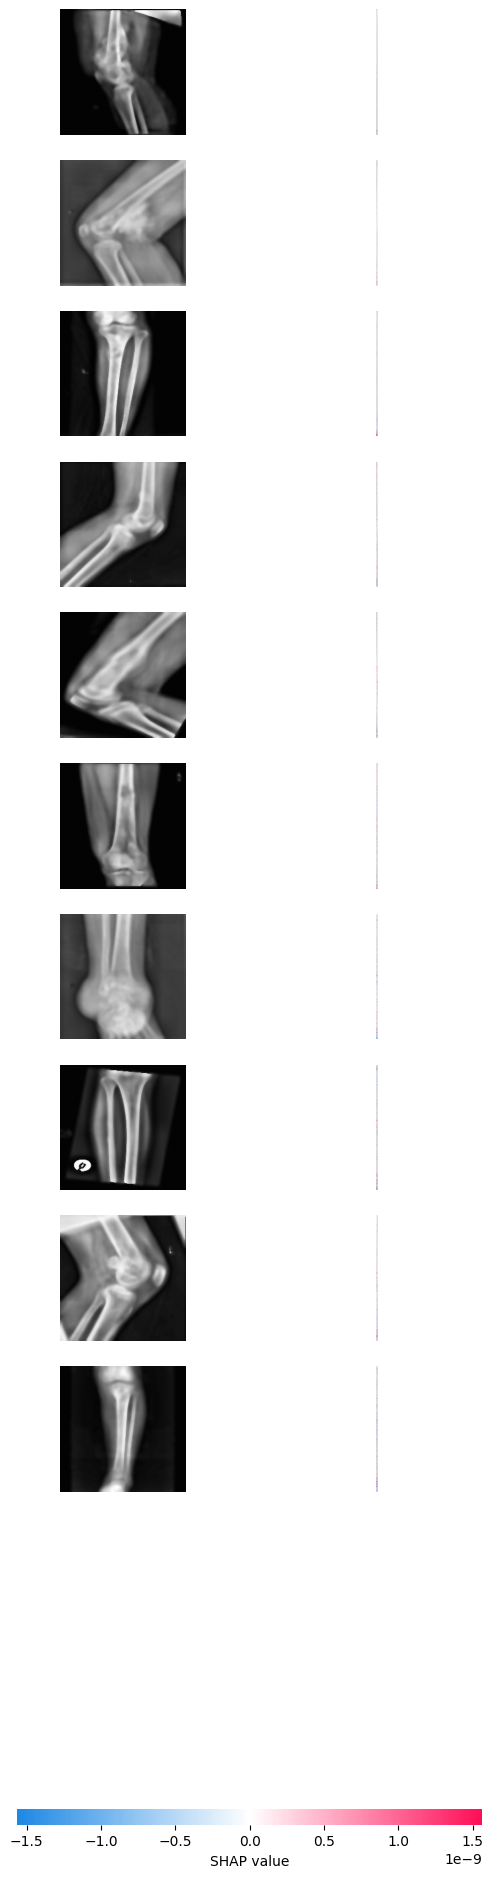

In [39]:
shap.image_plot(
    shap_values_cbam[malignant_idx],
    X_shap
)

In [40]:
np.save(
    "shap_baseline_malignant.npy",
    shap_values_baseline[malignant_idx]
)

In [41]:
np.save(
    "shap_cbam_malignant.npy",
    shap_values_cbam[malignant_idx]
)

In [42]:
plt.savefig(
    "shap_baseline.png",
    bbox_inches='tight'
)

<Figure size 640x480 with 0 Axes>

In [43]:
plt.savefig(
    "shap_cbam.png",
    bbox_inches='tight'
)

<Figure size 640x480 with 0 Axes>

In [44]:
model.save("/kaggle/working/mobilenet_baseline.keras")

In [45]:
model_cbam.save("/kaggle/working/mobilenet_cbam.keras")

In [46]:
import json

with open("history_baseline.json","w") as f:
    json.dump(history.history, f)

In [47]:
with open("history_cbam.json","w") as f:
    json.dump(history_cbam.history, f)

In [48]:
# ==========================================
# SAVE ALL EXPERIMENT RESULTS (FINAL)
# ==========================================

import os
import json
import shutil
import joblib
import pandas as pd
import numpy as np

from sklearn.metrics import (
    classification_report,
    confusion_matrix
)

print("="*70)
print("MENYIMPAN SELURUH HASIL EKSPERIMEN")
print("="*70)

SAVE_DIR = "/kaggle/working/hasil_experiment"

os.makedirs(SAVE_DIR, exist_ok=True)

# =====================================================
# SAVE MODELS
# =====================================================

try:
    model.save(f"{SAVE_DIR}/mobilenet_baseline.keras")
    print("✓ Baseline model saved")
except Exception as e:
    print("✗ Baseline model:", e)

try:
    model_cbam.save(f"{SAVE_DIR}/mobilenet_cbam.keras")
    print("✓ CBAM model saved")
except Exception as e:
    print("✗ CBAM model:", e)


# =====================================================
# SAVE TRAINING HISTORY
# =====================================================

try:
    pd.DataFrame(history.history).to_csv(
        f"{SAVE_DIR}/baseline_history.csv",
        index=False
    )
    print("✓ Baseline history saved")
except Exception as e:
    print("✗ Baseline history:", e)

try:
    pd.DataFrame(history_cbam.history).to_csv(
        f"{SAVE_DIR}/cbam_history.csv",
        index=False
    )
    print("✓ CBAM history saved")
except Exception as e:
    print("✗ CBAM history:", e)


# =====================================================
# BASELINE EVALUATION (AUTO)
# =====================================================

try:
    y_true_baseline
    y_pred_baseline
    print("✓ Baseline prediction found")

except:

    print("Recomputing baseline predictions...")

    y_true_baseline = []
    y_pred_baseline = []

    for i in range(len(test_gen)):

        X, y = test_gen[i]

        pred = model.predict(
            X,
            verbose=0
        )

        y_true_baseline.extend(
            np.argmax(y, axis=1)
        )

        y_pred_baseline.extend(
            np.argmax(pred, axis=1)
        )

    print("✓ Baseline prediction rebuilt")


# =====================================================
# CBAM EVALUATION (AUTO)
# =====================================================

try:
    y_true_cbam
    y_pred_cbam
    print("✓ CBAM prediction found")

except:

    print("Using current y_true/y_pred as CBAM results...")

    y_true_cbam = y_true.copy()
    y_pred_cbam = y_pred.copy()

    print("✓ CBAM prediction secured")


# =====================================================
# REPORTS
# =====================================================

report_baseline = classification_report(
    y_true_baseline,
    y_pred_baseline,
    target_names=train_gen.labels,
    output_dict=True
)

report_cbam = classification_report(
    y_true_cbam,
    y_pred_cbam,
    target_names=train_gen.labels,
    output_dict=True
)

pd.DataFrame(report_baseline).transpose().to_csv(
    f"{SAVE_DIR}/baseline_report.csv"
)

pd.DataFrame(report_cbam).transpose().to_csv(
    f"{SAVE_DIR}/cbam_report.csv"
)

print("✓ Classification reports saved")


# =====================================================
# CONFUSION MATRIX
# =====================================================

cm_baseline = confusion_matrix(
    y_true_baseline,
    y_pred_baseline
)

cm_cbam = confusion_matrix(
    y_true_cbam,
    y_pred_cbam
)

np.save(
    f"{SAVE_DIR}/cm_baseline.npy",
    cm_baseline
)

np.save(
    f"{SAVE_DIR}/cm_cbam.npy",
    cm_cbam
)

print("✓ Confusion matrices saved")


# =====================================================
# PREDICTION TABLES
# =====================================================

pred_df_baseline = pd.DataFrame({
    "actual": [
        train_gen.labels[i]
        for i in y_true_baseline
    ],
    "predicted": [
        train_gen.labels[i]
        for i in y_pred_baseline
    ]
})

pred_df_cbam = pd.DataFrame({
    "actual": [
        train_gen.labels[i]
        for i in y_true_cbam
    ],
    "predicted": [
        train_gen.labels[i]
        for i in y_pred_cbam
    ]
})

pred_df_baseline.to_csv(
    f"{SAVE_DIR}/baseline_predictions.csv",
    index=False
)

pred_df_cbam.to_csv(
    f"{SAVE_DIR}/cbam_predictions.csv",
    index=False
)

print("✓ Prediction tables saved")


# =====================================================
# SHAP
# =====================================================

try:

    malignant_idx = train_gen.label_map["malignant"]

    joblib.dump(
        shap_values_baseline,
        f"{SAVE_DIR}/shap_baseline.pkl"
    )

    np.save(
        f"{SAVE_DIR}/shap_baseline_malignant.npy",
        shap_values_baseline[malignant_idx]
    )

    print("✓ SHAP baseline saved")

except Exception as e:
    print("✗ SHAP baseline:", e)


try:

    malignant_idx = train_gen.label_map["malignant"]

    joblib.dump(
        shap_values_cbam,
        f"{SAVE_DIR}/shap_cbam.pkl"
    )

    np.save(
        f"{SAVE_DIR}/shap_cbam_malignant.npy",
        shap_values_cbam[malignant_idx]
    )

    print("✓ SHAP CBAM saved")

except Exception as e:
    print("✗ SHAP CBAM:", e)


# =====================================================
# LABEL MAPPING
# =====================================================

label_mapping = {
    i: label
    for i, label in enumerate(train_gen.labels)
}

with open(
    f"{SAVE_DIR}/label_mapping.json",
    "w"
) as f:
    json.dump(
        label_mapping,
        f,
        indent=4
    )

print("✓ Label mapping saved")


# =====================================================
# PREPROCESS CONFIG
# =====================================================

preprocessing_config = {
    "image_size": 224,
    "grayscale": True,
    "bilateral_filter": {
        "d": 9,
        "sigmaColor": 75,
        "sigmaSpace": 75
    },
    "median_blur": 5,
    "clahe": {
        "clipLimit": 2.0,
        "tileGridSize": [8, 8]
    }
}

with open(
    f"{SAVE_DIR}/preprocessing_config.json",
    "w"
) as f:
    json.dump(
        preprocessing_config,
        f,
        indent=4
    )

print("✓ Preprocessing config saved")


# =====================================================
# CLASS NAMES
# =====================================================

np.save(
    f"{SAVE_DIR}/class_names.npy",
    np.array(train_gen.labels)
)

print("✓ Class names saved")


# =====================================================
# ZIP
# =====================================================

zip_path = shutil.make_archive(
    SAVE_DIR,
    "zip",
    SAVE_DIR
)

print("\n" + "="*70)
print("SEMUA HASIL BERHASIL DISIMPAN")
print("="*70)

print("\nZIP FILE:")
print(zip_path)

print("\nDOWNLOAD:")
print("/kaggle/working/hasil_experiment.zip")

MENYIMPAN SELURUH HASIL EKSPERIMEN
✓ Baseline model saved
✓ CBAM model saved
✓ Baseline history saved
✓ CBAM history saved
Recomputing baseline predictions...
✓ Baseline prediction rebuilt
Using current y_true/y_pred as CBAM results...
✓ CBAM prediction secured
✓ Classification reports saved
✓ Confusion matrices saved
✓ Prediction tables saved
✓ SHAP baseline saved
✓ SHAP CBAM saved
✓ Label mapping saved
✓ Preprocessing config saved
✓ Class names saved

SEMUA HASIL BERHASIL DISIMPAN

ZIP FILE:
/kaggle/working/hasil_experiment.zip

DOWNLOAD:
/kaggle/working/hasil_experiment.zip
